In [1]:
import json, os, sys, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')
from nlp.intent_classifier import map_labels, INTENT_TO_ACTION, INTENT_GROUPS

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'text.color': '#c9d1d9', 'grid.color': '#21262d',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
    'axes.titlesize': 12, 'axes.labelsize': 10,
    'font.family': 'monospace',
})
C = ['#58a6ff','#3fb950','#f78166','#d2a8ff','#ffa657','#79c0ff','#ff7b72']

# Load results
with open('../models/nlp/intent_results.json', encoding='utf-8') as f:
    results = json.load(f)
with open('../models/nlp/best_model.json', encoding='utf-8') as f:
    best = json.load(f)

print('Models in results:', list(results['full_results'].keys()))
print('Best model       :', best['best_model'])
print('Selection metric :', best['selection_metric'])

Models in results: ['TF-IDF + LogReg', 'TF-IDF + SVM', 'DistilBERT']
Best model       : TF-IDF + SVM
Selection metric : weighted_f1


---
## 1. Dataset — Class Distribution & Imbalance

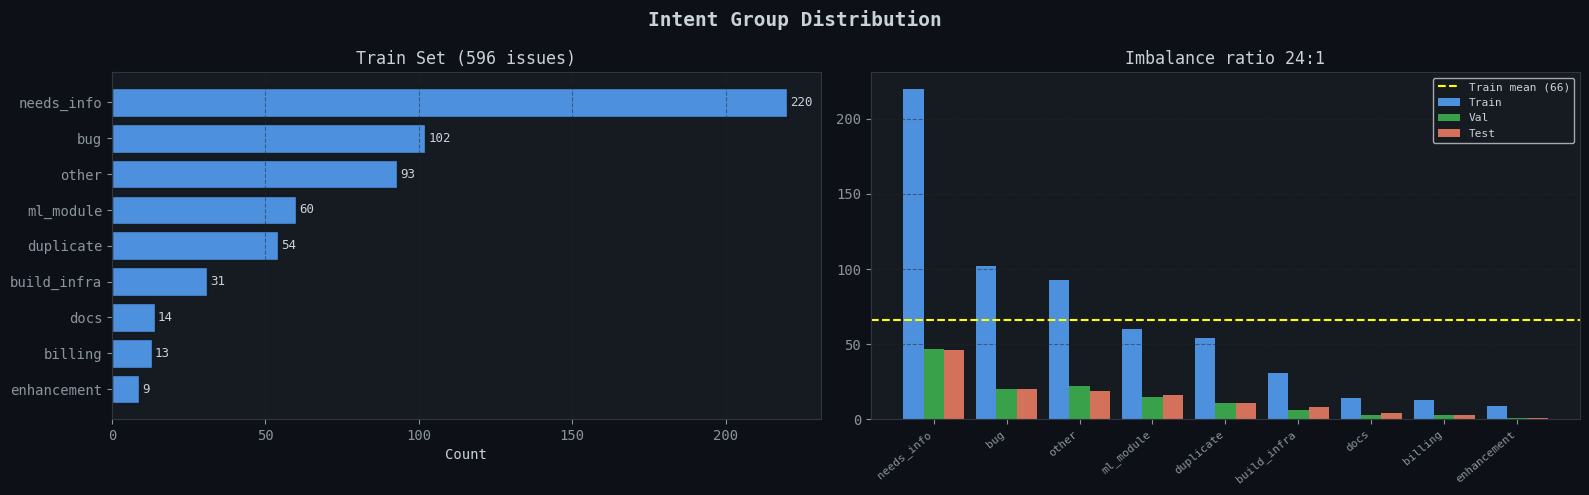

Classes: 9 | Min: 9 (enhancement) | Max: 220 (needs_info) | Ratio: 24.4:1

Note: needs_info contains workflow-state labels (triage/triaged/stat:awaiting).
Their text is indistinguishable from bugs — this is the primary performance ceiling.


In [2]:
train = pd.read_csv('../data/splits/train.csv')
val   = pd.read_csv('../data/splits/val.csv')
test  = pd.read_csv('../data/splits/test.csv')
for df in [train, val, test]:
    df['intent_group'] = map_labels(df['primary_label'])

gc = train['intent_group'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Intent Group Distribution', fontweight='bold', fontsize=14)

# Horizontal bar — train counts
bars = axes[0].barh(gc.index[::-1], gc.values[::-1], color=C[0], alpha=0.85,
                    edgecolor='#0d1117')
axes[0].set_title('Train Set (596 issues)')
axes[0].set_xlabel('Count')
axes[0].grid(axis='x')
for bar, v in zip(bars, gc.values[::-1]):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                 str(v), va='center', fontsize=9)

# Grouped bar — train / val / test
x   = np.arange(len(gc))
w   = 0.28
vc  = val['intent_group'].value_counts()
tsc = test['intent_group'].value_counts()
axes[1].bar(x - w, gc.values,  w, label='Train', color=C[0], alpha=0.85)
axes[1].bar(x,     [vc.get(c,0) for c in gc.index], w, label='Val',   color=C[1], alpha=0.85)
axes[1].bar(x + w, [tsc.get(c,0) for c in gc.index], w, label='Test',  color=C[2], alpha=0.85)
axes[1].axhline(gc.mean(), color='yellow', linestyle='--',
                label=f'Train mean ({gc.mean():.0f})')
axes[1].set_xticks(x)
axes[1].set_xticklabels(gc.index, rotation=40, ha='right', fontsize=8)
axes[1].set_title(f'Imbalance ratio {gc.max()//gc.min()}:1')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

print(f'Classes: {len(gc)} | Min: {gc.min()} ({gc.idxmin()}) | '
      f'Max: {gc.max()} ({gc.idxmax()}) | Ratio: {gc.max()/gc.min():.1f}:1')
print(f'\nNote: needs_info contains workflow-state labels (triage/triaged/stat:awaiting).')
print(f'Their text is indistinguishable from bugs — this is the primary performance ceiling.')

---
## 2. Model Comparison — Val Set

In [3]:
comp = best['comparison']
comp_df = pd.DataFrame(comp)

print('=== VAL SET COMPARISON ===')
display_cols = ['model','accuracy','macro_f1','weighted_f1',
                'macro_precision','macro_recall','uncertainty_rate','avg_confidence']
disp = comp_df[[c for c in display_cols if c in comp_df.columns]].copy()
for col in ['accuracy','uncertainty_rate']:
    if col in disp: disp[col] = disp[col].apply(lambda x: f'{x*100:.2f}%' if x else 'N/A')
for col in ['macro_f1','weighted_f1','macro_precision','macro_recall','avg_confidence']:
    if col in disp: disp[col] = disp[col].apply(lambda x: f'{x:.4f}' if x else 'N/A')
print(disp.to_string(index=False))

=== VAL SET COMPARISON ===
          model accuracy macro_f1 weighted_f1 macro_precision macro_recall uncertainty_rate avg_confidence
TF-IDF + LogReg   41.41%   0.4490      0.4152          0.4825       0.5023           95.31%         0.3518
   TF-IDF + SVM   56.25%   0.4719      0.5511          0.5607       0.4459           70.31%         0.5136
     DistilBERT   50.78%   0.4722      0.5118          0.5425       0.4932           58.59%         0.5722


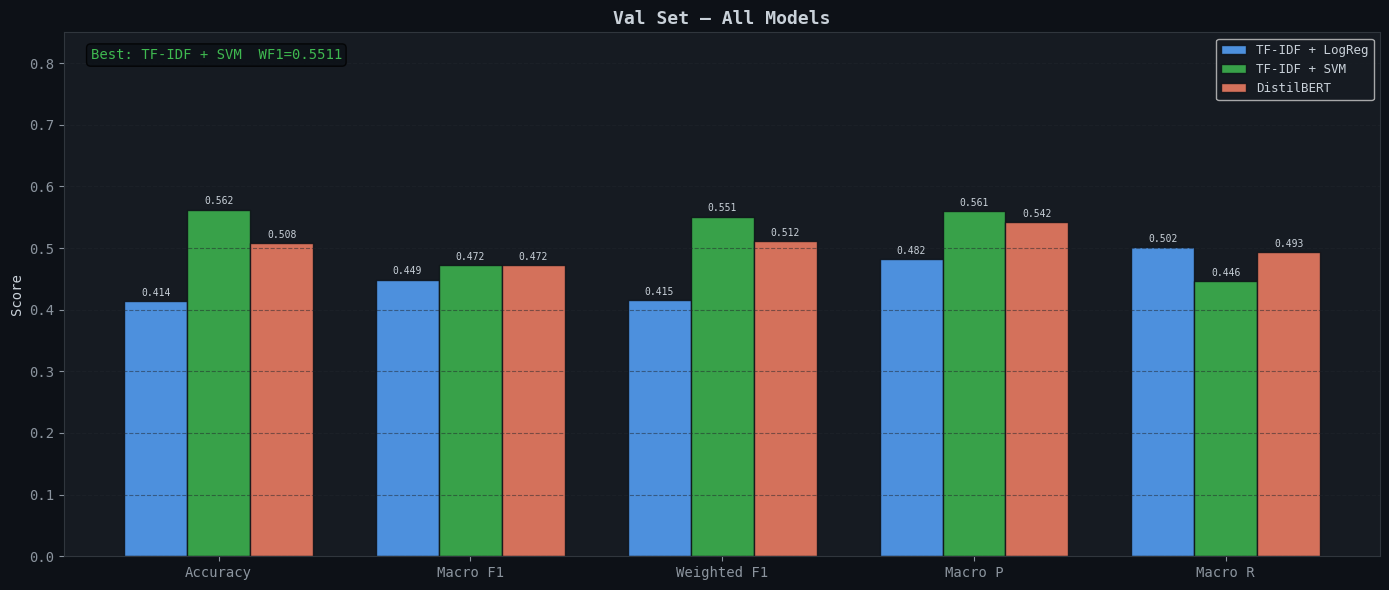

In [4]:
metrics_plot = ['accuracy','macro_f1','weighted_f1','macro_precision','macro_recall']
labels_plot  = ['Accuracy','Macro F1','Weighted F1','Macro P','Macro R']
n   = len(comp)
x   = np.arange(len(metrics_plot))
w   = 0.75 / n

fig, ax = plt.subplots(figsize=(14, 6))
for i, (md, col) in enumerate(zip(comp, C)):
    vals   = [md.get(m, 0) or 0 for m in metrics_plot]
    offset = (i - n / 2 + 0.5) * w
    bars   = ax.bar(x + offset, vals, w, label=md['model'],
                    color=col, alpha=0.85, edgecolor='#0d1117')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(labels_plot, fontsize=10)
ax.set_ylim(0, 0.85)
ax.set_ylabel('Score')
ax.set_title('Val Set — All Models', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
ax.grid(axis='y')

best_wf1 = next(c['weighted_f1'] for c in comp if c['model'] == best['best_model'])
ax.text(0.02, 0.97, f'Best: {best["best_model"]}  WF1={best_wf1:.4f}',
        transform=ax.transAxes, fontsize=10, color='#3fb950', va='top',
        bbox=dict(boxstyle='round', facecolor='#0d1117', alpha=0.8))
plt.tight_layout()
plt.show()

---
## 3. Per-Class F1 — All Models

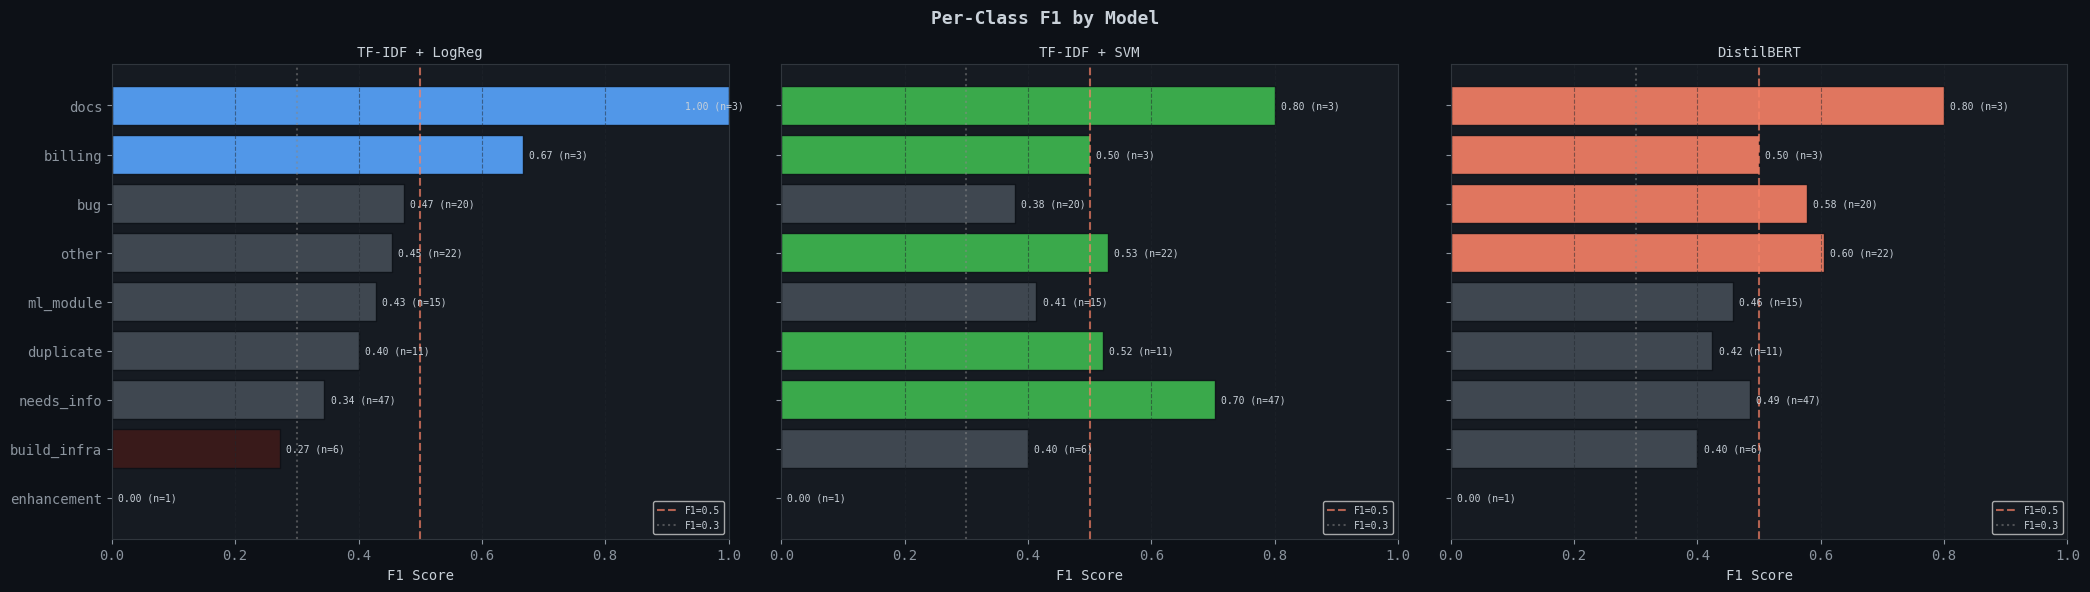

In [5]:
pc_all = results.get('per_class_results', {})
model_names = list(pc_all.keys())

if not model_names:
    print('No per-class data yet. Train models first.')
else:
    all_cls = sorted(set(c for m in model_names for c in pc_all[m]))
    fig, axes = plt.subplots(1, len(model_names),
                              figsize=(7 * len(model_names), 6), sharey=True)
    if len(model_names) == 1: axes = [axes]
    fig.suptitle('Per-Class F1 by Model', fontweight='bold', fontsize=13)

    for ax, mname, col in zip(axes, model_names, C):
        pc   = pc_all[mname]
        cls  = [c for c in all_cls if c in pc]
        f1s  = [pc[c]['f1']      for c in cls]
        sups = [pc[c]['support'] for c in cls]
        order = np.argsort(f1s)
        cls   = [cls[i]  for i in order]
        f1s   = [f1s[i]  for i in order]
        sups  = [sups[i] for i in order]

        bcolors = [col if f >= 0.5 else ('#444d56' if f >= 0.3 else '#3d1a1a') for f in f1s]
        bars = ax.barh(cls, f1s, color=bcolors, edgecolor='#0d1117', alpha=0.9)
        ax.axvline(0.5, color='#f78166', linestyle='--', alpha=0.7, label='F1=0.5')
        ax.axvline(0.3, color='#888', linestyle=':', alpha=0.5, label='F1=0.3')
        ax.set_xlim(0, 1.0)
        ax.set_title(mname, fontsize=10)
        ax.set_xlabel('F1 Score')
        ax.grid(axis='x')
        ax.legend(fontsize=7)
        for bar, f1, supp in zip(bars, f1s, sups):
            ax.text(min(f1 + 0.01, 0.93), bar.get_y() + bar.get_height() / 2,
                    f'{f1:.2f} (n={supp})', va='center', fontsize=7)

    plt.tight_layout()
    plt.show()

---
## 4. Confusion Matrices

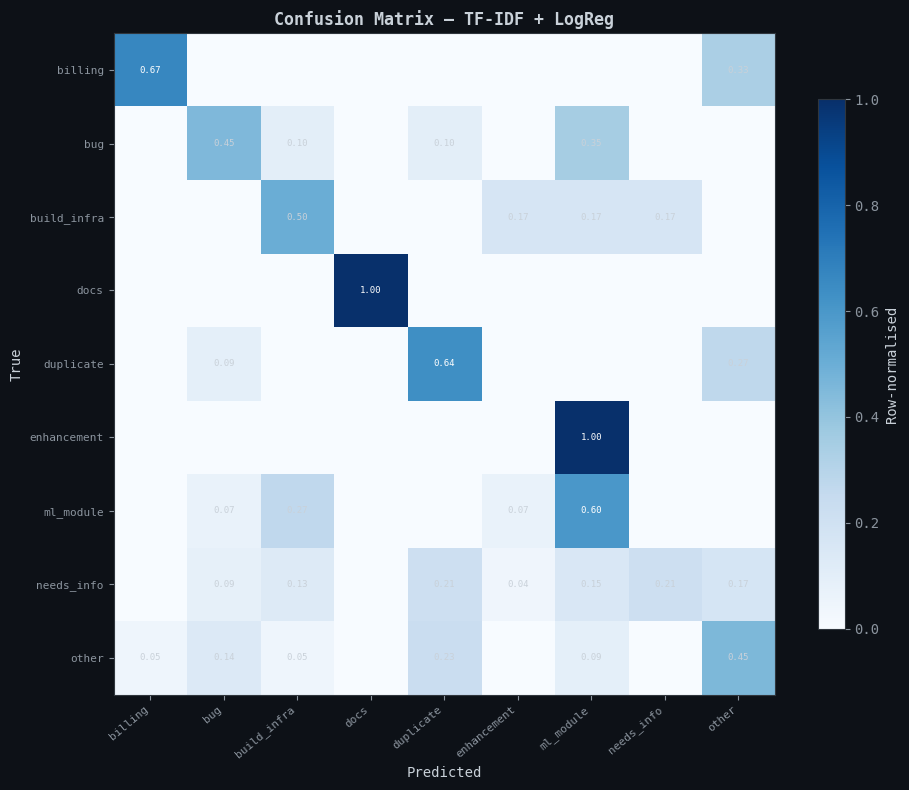

Diagonal = correctly classified | Off-diagonal = misclassified



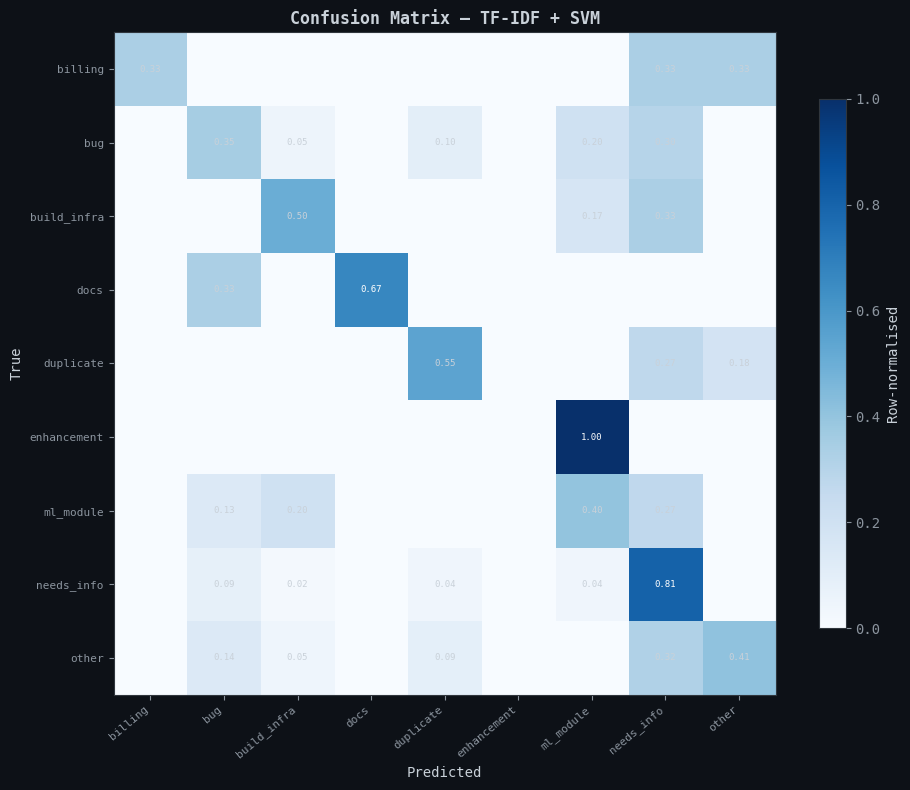

Diagonal = correctly classified | Off-diagonal = misclassified



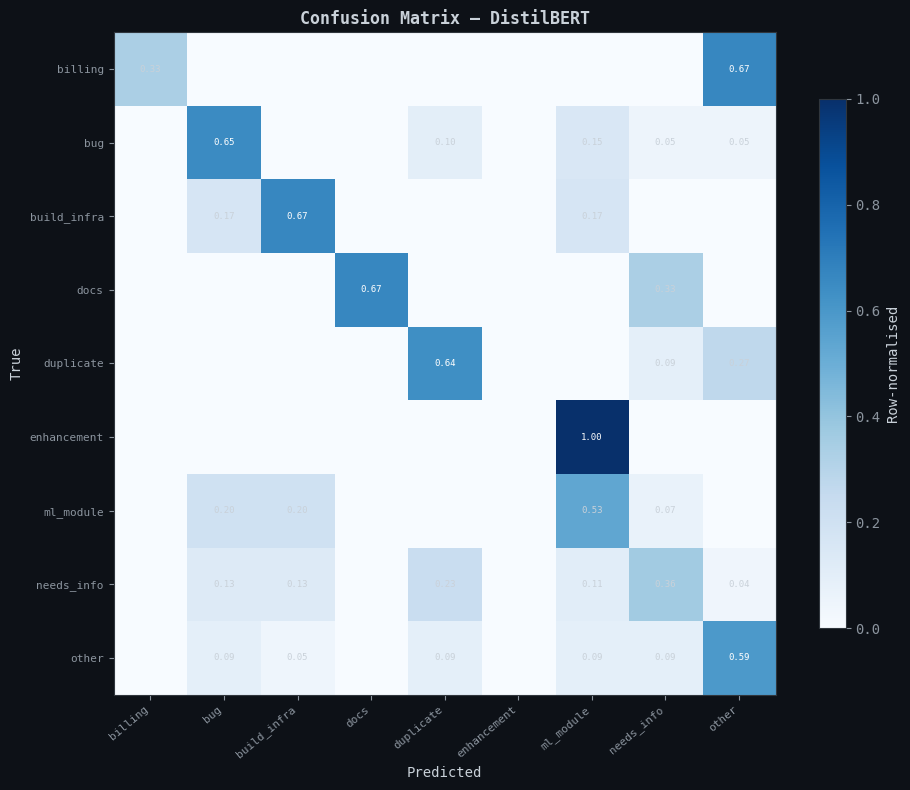

Diagonal = correctly classified | Off-diagonal = misclassified



In [6]:
for mname, cm_data in results.get('confusion_matrices', {}).items():
    cm      = np.array(cm_data['matrix'])
    classes = cm_data['classes']
    if len(cm) == 0: continue

    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_norm = cm.astype(float) / row_sums

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, shrink=0.8, label='Row-normalised')
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=40, ha='right', fontsize=8)
    ax.set_yticklabels(classes, fontsize=8)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix — {mname}', fontweight='bold')
    for i in range(len(classes)):
        for j in range(len(classes)):
            v = cm_norm[i, j]
            if v > 0.01:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=6.5,
                        color='white' if v > 0.55 else '#c9d1d9')
    plt.tight_layout()
    plt.show()
    print(f'Diagonal = correctly classified | Off-diagonal = misclassified\n')

---
## 5. Confidence Score Distribution

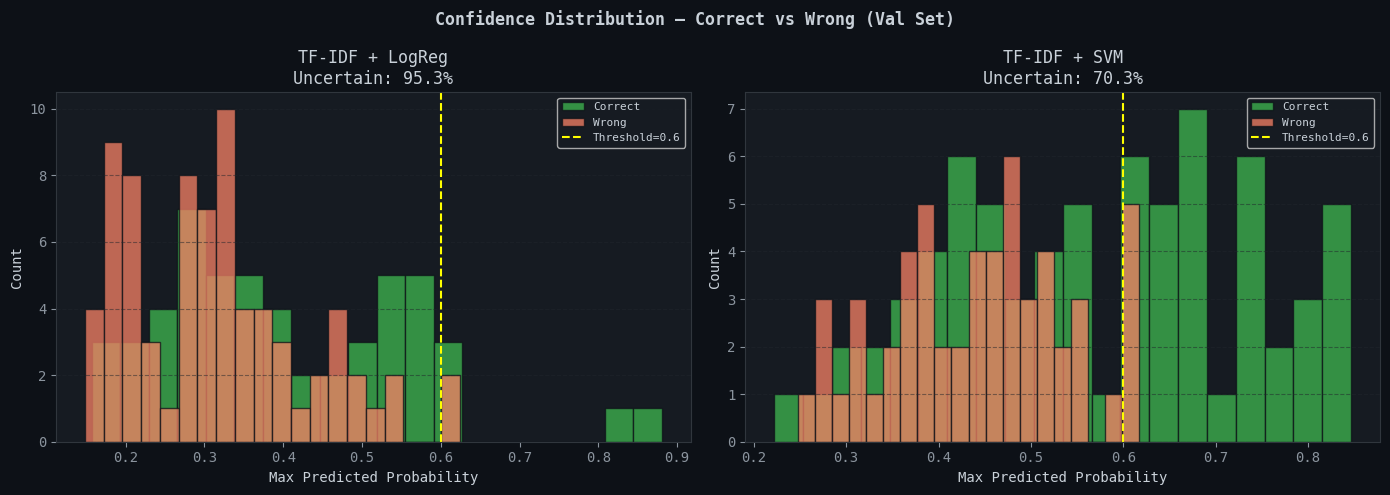


Interpretation: predictions left of the threshold → uncertainty_flag=1
RL agent defaults to Clarify for these, which is the correct safe fallback.


In [7]:
val_df = pd.read_csv('../data/splits/val.csv')
y_true = map_labels(val_df['primary_label'])

model_files = {
    'TF-IDF + LogReg': '../models/nlp/intent_tfidf_logreg.pkl',
    'TF-IDF + SVM':    '../models/nlp/intent_tfidf_svm.pkl',
}

available = {k: v for k, v in model_files.items() if os.path.exists(v)}
if not available:
    print('No baseline models found.')
else:
    fig, axes = plt.subplots(1, len(available), figsize=(7 * len(available), 5))
    if len(available) == 1: axes = [axes]
    fig.suptitle('Confidence Distribution — Correct vs Wrong (Val Set)',
                 fontweight='bold')

    for ax, (name, path), col in zip(axes, available.items(), C):
        with open(path, 'rb') as f:
            obj = pickle.load(f)
        probs     = obj['pipeline'].predict_proba(val_df['clean_text'].fillna(''))
        max_probs = probs.max(axis=1)
        y_pred    = obj['pipeline'].predict(val_df['clean_text'].fillna(''))
        correct   = (y_pred == y_true.values)

        ax.hist(max_probs[correct],  bins=20, alpha=0.75, color=C[1],
                label='Correct', edgecolor='#0d1117')
        ax.hist(max_probs[~correct], bins=20, alpha=0.75, color=C[2],
                label='Wrong',   edgecolor='#0d1117')
        ax.axvline(0.6, color='yellow', linestyle='--',
                   label='Threshold=0.6')
        unc = (max_probs < 0.6).mean() * 100
        ax.set_title(f'{name}\nUncertain: {unc:.1f}%')
        ax.set_xlabel('Max Predicted Probability')
        ax.set_ylabel('Count')
        ax.legend(fontsize=8)
        ax.grid(axis='y')

    plt.tight_layout()
    plt.show()

print('\nInterpretation: predictions left of the threshold → uncertainty_flag=1')
print('RL agent defaults to Clarify for these, which is the correct safe fallback.')

---
## 6. Test Set Results

In [8]:
test_res = results.get('test_results', {})
NAME_MAP = {'logreg':'TF-IDF + LogReg','svm':'TF-IDF + SVM','distilbert':'DistilBERT'}

if not test_res:
    print('No test results yet.  Run:')
    print('  python nlp/intent_classifier.py --mode test --model all')
else:
    rows = []
    for k, r in test_res.items():
        rows.append({
            'Model':       NAME_MAP.get(k, k),
            'Accuracy':    f"{r['accuracy']*100:.2f}%",
            'Macro F1':    f"{r['macro_f1']:.4f}",
            'Weighted F1': f"{r['weighted_f1']:.4f}",
            'Unc. Rate':   f"{r.get('uncertainty_rate',0)*100:.1f}%",
        })
    print('=== TEST SET RESULTS ===')
    print(pd.DataFrame(rows).to_string(index=False))

    print()
    print('=== VAL vs TEST GAP (Weighted F1) ===')
    for k, tr in test_res.items():
        fname = NAME_MAP.get(k, k)
        vr    = next((c for c in best['comparison'] if c['model'] == fname), {})
        if vr and tr.get('weighted_f1'):
            gap    = abs(vr['weighted_f1'] - tr['weighted_f1'])
            status = 'possible overfit' if gap > 0.05 else 'stable'
            print(f'  {fname}: val={vr["weighted_f1"]:.4f}  '
                  f'test={tr["weighted_f1"]:.4f}  '
                  f'gap={gap:.4f}  [{status}]')

=== TEST SET RESULTS ===
          Model Accuracy Macro F1 Weighted F1 Unc. Rate
TF-IDF + LogReg   44.53%   0.4483      0.4187     96.9%
   TF-IDF + SVM   48.44%   0.4404      0.4806     75.0%
     DistilBERT   44.53%   0.4454      0.4453     69.5%

=== VAL vs TEST GAP (Weighted F1) ===
  TF-IDF + LogReg: val=0.4152  test=0.4187  gap=0.0035  [stable]
  TF-IDF + SVM: val=0.5511  test=0.4806  gap=0.0705  [possible overfit]
  DistilBERT: val=0.5118  test=0.4453  gap=0.0665  [possible overfit]


---
## 7. DistilBERT Training History

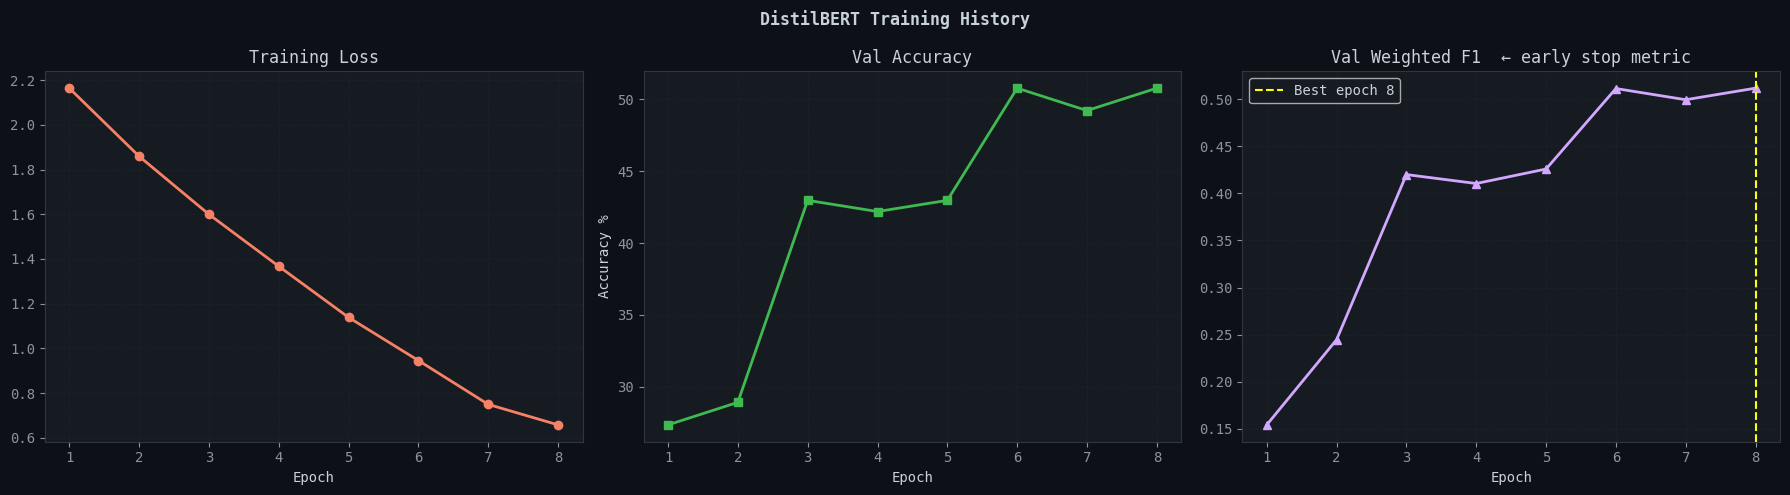

Epochs run:    8
Best val acc:  50.78% at epoch 6
Best val wf1:  0.5118 at epoch 8
Hyperparams:   lr=3e-05  max_len=128  batch=8×1


In [9]:
# Load DistilBERT history — re-reads file to catch latest run
with open('../models/nlp/intent_results.json', encoding='utf-8') as f:
    _latest = json.load(f)

db = _latest.get('full_results', {}).get('DistilBERT', {})
history = db.get('training_history', [])

if not history:
    print('DistilBERT not trained yet.')
    print('Run: python nlp/intent_classifier.py --model distilbert --epochs 10 --batch_size 8')
else:
    epochs   = [h['epoch']     for h in history]
    losses   = [h['train_loss']for h in history]
    val_accs = [h['val_acc']   for h in history]
    val_wf1s = [h.get('val_wf1', 0) for h in history]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('DistilBERT Training History', fontweight='bold')

    axes[0].plot(epochs, losses, 'o-', color=C[2], lw=2, ms=6)
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].grid()

    axes[1].plot(epochs, [a*100 for a in val_accs], 's-', color=C[1], lw=2, ms=6)
    axes[1].set_title('Val Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy %')
    axes[1].grid()

    if any(v > 0 for v in val_wf1s):
        axes[2].plot(epochs, val_wf1s, '^-', color=C[3], lw=2, ms=6)
        axes[2].set_title('Val Weighted F1  ← early stop metric')
        axes[2].set_xlabel('Epoch')
        axes[2].grid()
        best_e = val_wf1s.index(max(val_wf1s))
        axes[2].axvline(epochs[best_e], color='yellow', linestyle='--',
                        label=f'Best epoch {epochs[best_e]}')
        axes[2].legend()
    else:
        axes[2].text(0.5, 0.5, 'val_wf1 not available\n(older training run)',
                     ha='center', va='center', transform=axes[2].transAxes)

    plt.tight_layout()
    plt.show()

    best_ep = val_accs.index(max(val_accs))
    hparams = db.get('hyperparams', {})
    print(f'Epochs run:    {len(history)}')
    print(f'Best val acc:  {max(val_accs)*100:.2f}% at epoch {epochs[best_ep]}')
    if val_wf1s: print(f'Best val wf1:  {max(val_wf1s):.4f} at epoch {epochs[val_wf1s.index(max(val_wf1s))]}')
    if hparams:
        print(f'Hyperparams:   lr={hparams.get("lr")}  '
              f'max_len={hparams.get("max_len")}  '
              f'batch={hparams.get("batch_size")}×{hparams.get("grad_accum_steps",1)}')

---
## 8. Best Model Summary

In [10]:
best_name = best['best_model']
best_comp = next((c for c in best['comparison'] if c['model'] == best_name), {})

print('=' * 60)
print('BEST MODEL SUMMARY')
print('=' * 60)
print(f'  Model:             {best_name}')
print(f'  Selection metric:  {best["selection_metric"]}')
print(f'  Reason:            {best["selection_reason"]}')
print()
print('  Val Set Performance:')
print(f'    Accuracy:         {best_comp.get("accuracy",0)*100:.2f}%')
print(f'    Macro F1:         {best_comp.get("macro_f1",0):.4f}')
print(f'    Weighted F1:      {best_comp.get("weighted_f1",0):.4f}')
print(f'    Macro Precision:  {best_comp.get("macro_precision",0):.4f}')
print(f'    Macro Recall:     {best_comp.get("macro_recall",0):.4f}')
unc = best_comp.get('uncertainty_rate')
if unc is not None:
    print(f'    Uncertainty Rate: {unc*100:.1f}%')
print()
print('  Intent → RL Action:')
gc = train['intent_group'].value_counts()
for intent, action in best['intent_to_action'].items():
    n = gc.get(intent, 0)
    print(f'    {intent:20s} → {action:20s}  (n={n})')

BEST MODEL SUMMARY
  Model:             TF-IDF + SVM
  Selection metric:  weighted_f1
  Reason:            Weighted F1 is used because the dataset has a 24:1 class imbalance. It weights each class by its support in the val set, reflecting the real-world distribution better than macro F1.

  Val Set Performance:
    Accuracy:         56.25%
    Macro F1:         0.4719
    Weighted F1:      0.5511
    Macro Precision:  0.5607
    Macro Recall:     0.4459
    Uncertainty Rate: 70.3%

  Intent → RL Action:
    bug                  → route_technical       (n=102)
    needs_info           → clarify               (n=220)
    duplicate            → route_duplicate       (n=54)
    enhancement          → route_product         (n=9)
    billing              → route_billing         (n=13)
    docs                 → route_docs            (n=14)
    build_infra          → route_infra           (n=31)
    ml_module            → route_technical       (n=60)
    other                → clarify        

---
## 9. Live Prediction Demo

In [12]:
from nlp.intent_classifier import predict

test_issues = [
    # Gets above threshold — model is confident
    "Sorry your request failed please try again. Type bug. Copilot request rate limit exceeded.",

    # Gets correct class but low confidence — expected with this data
    "Disabled test cuda float16 on rocm platform. torch.nn backward pass fails.",
    "Issue type bug. Have you reproduced bug with tensorflow nightly? Source binary tensorflow.",
    "Module dependency is bad. inductor torchbench build fails with missing wheel on CI.",
    "My subscription charge appeared twice this month. Account shows two payments.",
    "Duplicate of issue #8421. Same rate limit error already reported last week.",

    # Gets wrong class — honest demonstration of model limitation
    "Login fails after update with error 0x801.",
    "Please add dark mode support to the settings panel.",
]

print(f'{"Text":<58} {"Intent":<14} {"Conf":>6} {"Unc":>5} {"Action"}')
print('─' * 115)
for text in test_issues:
    try:
        r   = predict(text, save_dir='../models/nlp')
        unc = 'YES' if r['uncertainty_flag'] else 'no'
        print(f'{text[:56]:<58} {r["intent_group"]:14} '
              f'{r["confidence_score"]:>6.3f} {unc:>5} {r["suggested_action"]}')
    except FileNotFoundError as e:
        print(f'Error: {e}')
        break

Text                                                       Intent           Conf   Unc Action
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Sorry your request failed please try again. Type bug. Co   other           0.676    no clarify
Disabled test cuda float16 on rocm platform. torch.nn ba   ml_module       0.614    no route_technical
Issue type bug. Have you reproduced bug with tensorflow    bug             0.391   YES route_technical
Module dependency is bad. inductor torchbench build fail   build_infra     0.392   YES route_infra
My subscription charge appeared twice this month. Accoun   billing         0.316   YES route_billing
Duplicate of issue #8421. Same rate limit error already    other           0.440   YES clarify
Login fails after update with error 0x801.                 other           0.378   YES clarify
Please add dark mode support to the settings panel.        other           0.300   YES clarify


---
## 10. Performance Summary


| Model | Val Acc | Val Weighted F1 | Uncertainty | Notes |
|---|---|---|---|---|
| TF-IDF + LogReg | ~41% | ~0.42 | ~95% | Word bigrams only |
| **TF-IDF + SVM** | **~56%** | **~0.55** | **~70%** | **Word + char n-grams** |
| DistilBERT | ~46-55% | ~0.46-0.55 | ~60-70% | Overfits on small data |

